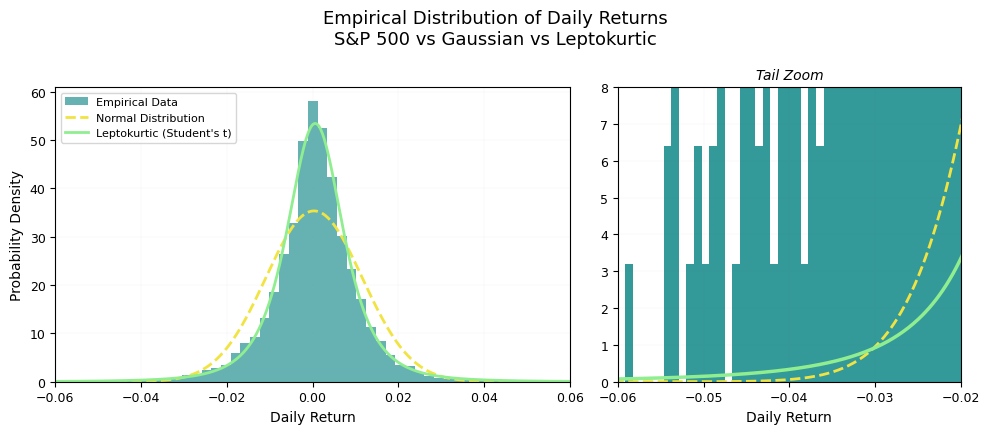

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.stats import norm, t

# Figure 1.5 — Leptokurtosis and heavy tails
# This notebook compares the empirical distribution of S&P 500 daily returns
# with a Gaussian benchmark and a fitted Student's t distribution

# Output folder on the local machine
OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style settings
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# Data download and cleaning
df = yf.download(
    "^GSPC",
    start="1980-01-01",
    end="2024-12-31",
    interval="1d",
    progress=False
)

# Handle possible multi-level columns returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Compute daily logarithmic returns
returns = np.log(df["Close"] / df["Close"].shift(1)).dropna()

# Fit the benchmark distributions
mu, std = norm.fit(returns)
df_fit, loc_fit, scale_fit = t.fit(returns)

# Density grid
x = np.linspace(-0.1, 0.1, 1000)
p_norm = norm.pdf(x, mu, std)
p_t = t.pdf(x, df_fit, loc_fit, scale_fit)

# Figure construction with central distribution and tail zoom
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [1.5, 1]}
)

fig.suptitle(
    "Empirical Distribution of Daily Returns\nS&P 500 vs Gaussian vs Leptokurtic",
    fontsize=13,
    y=0.89
)

# Panel 1: full empirical distribution around the center
ax1.hist(
    returns,
    bins=150,
    density=True,
    alpha=0.6,
    color="#008080",
    label="Empirical Data"
)

ax1.plot(
    x,
    p_norm,
    "--",
    color="#f1e442",
    linewidth=2,
    label="Normal Distribution"
)

ax1.plot(
    x,
    p_t,
    color="#90ee90",
    linewidth=2,
    label="Leptokurtic (Student's t)"
)

ax1.set_xlim(-0.06, 0.06)
ax1.set_ylabel("Probability Density")
ax1.legend(fontsize=8, loc="upper left")

# Panel 2: left-tail zoom
ax2.hist(
    returns,
    bins=45,
    range=(-0.06, -0.02),
    density=True,
    alpha=0.8,
    color="#008080"
)

ax2.plot(
    x,
    p_norm,
    "--",
    color="#f1e442",
    linewidth=2
)

ax2.plot(
    x,
    p_t,
    color="#90ee90",
    linewidth=2.5
)

ax2.set_xlim(-0.06, -0.02)
ax2.set_ylim(0, 8)
ax2.set_title("Tail Zoom", fontsize=10, fontstyle="italic")
ax2.set_xticks([-0.06, -0.05, -0.04, -0.03, -0.02])

for ax in [ax1, ax2]:
    ax.grid(color="grey", linestyle="-", linewidth=0.1, alpha=0.3)
    ax.set_xlabel("Daily Return")

# Export figure for the thesis
plt.tight_layout(rect=[0, 0.03, 1, 0.91])
output_path = OUTPUT_DIR / "fig_1_5_leptokurtosis.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()